In [1]:
import numpy as np
import os
from astropy.io import fits 

base_path="../data/2018_08_25" 
freq_2=os.path.join(base_path,"egress_pwr_02.5-03.5mHz_z0000km.fits")
freq_3=os.path.join(base_path,"egress_pwr_03.5-04.5mHz_z0000km.fits")
freq_4=os.path.join(base_path,"egress_pwr_04.5-05.5mHz_z0000km.fits")
freq_5=os.path.join(base_path,"egress_pwr_05.0-07.0mHz_z0000km.fits")
freq_7=os.path.join(base_path,"egress_pwr_07.0-09.0mHz_z0000km.fits")
freq_9=os.path.join(base_path,"egress_pwr_09.0-11.0mHz_z0000km.fits")

with fits.open(freq_5) as hdul5:
    hdr5=hdul5[0].header
    egression_pwr_5=hdul5[0].data
print(hdr5)

SIMPLE  =                    T                                                  BITPIX  =                  -32                                                  NAXIS   =                    2                                                  NAXIS1  =                 1024                                                  NAXIS2  =                 1024                                                  DAXIS1  =         5.000000E-04                                                  DAXIS2  =         5.000000E-04                                                  X0      =                512.0                                                  Y0      =                512.0                                                  DSUN_OBS=      151247846538.50                                                  OBS_L0  =           104.800728                                                  OBS_B0  =             7.031806                                                  REF_L0  =               104.89          

 [astropy.io.fits.verify]


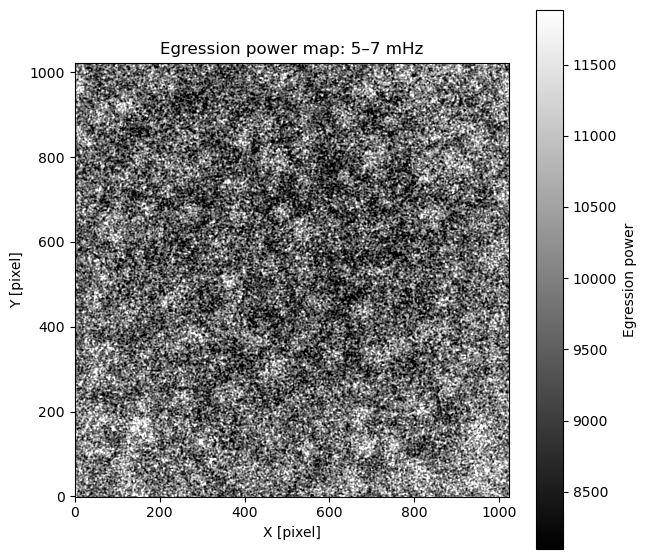

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.imshow(
    egression_pwr_5,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(egression_pwr_5,5),
    vmax=np.percentile(egression_pwr_5,98)
)

plt.colorbar(label="Egression power")
plt.title("Egression power map: 5–7 mHz")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")

plt.show()

## Detecting supergranules through the egression power map at 6mHz
Through the egression power map between frequencies of 5mHz-7mHz it is possible to observe the supergranules as a light bubbles.

Detected regions: 114


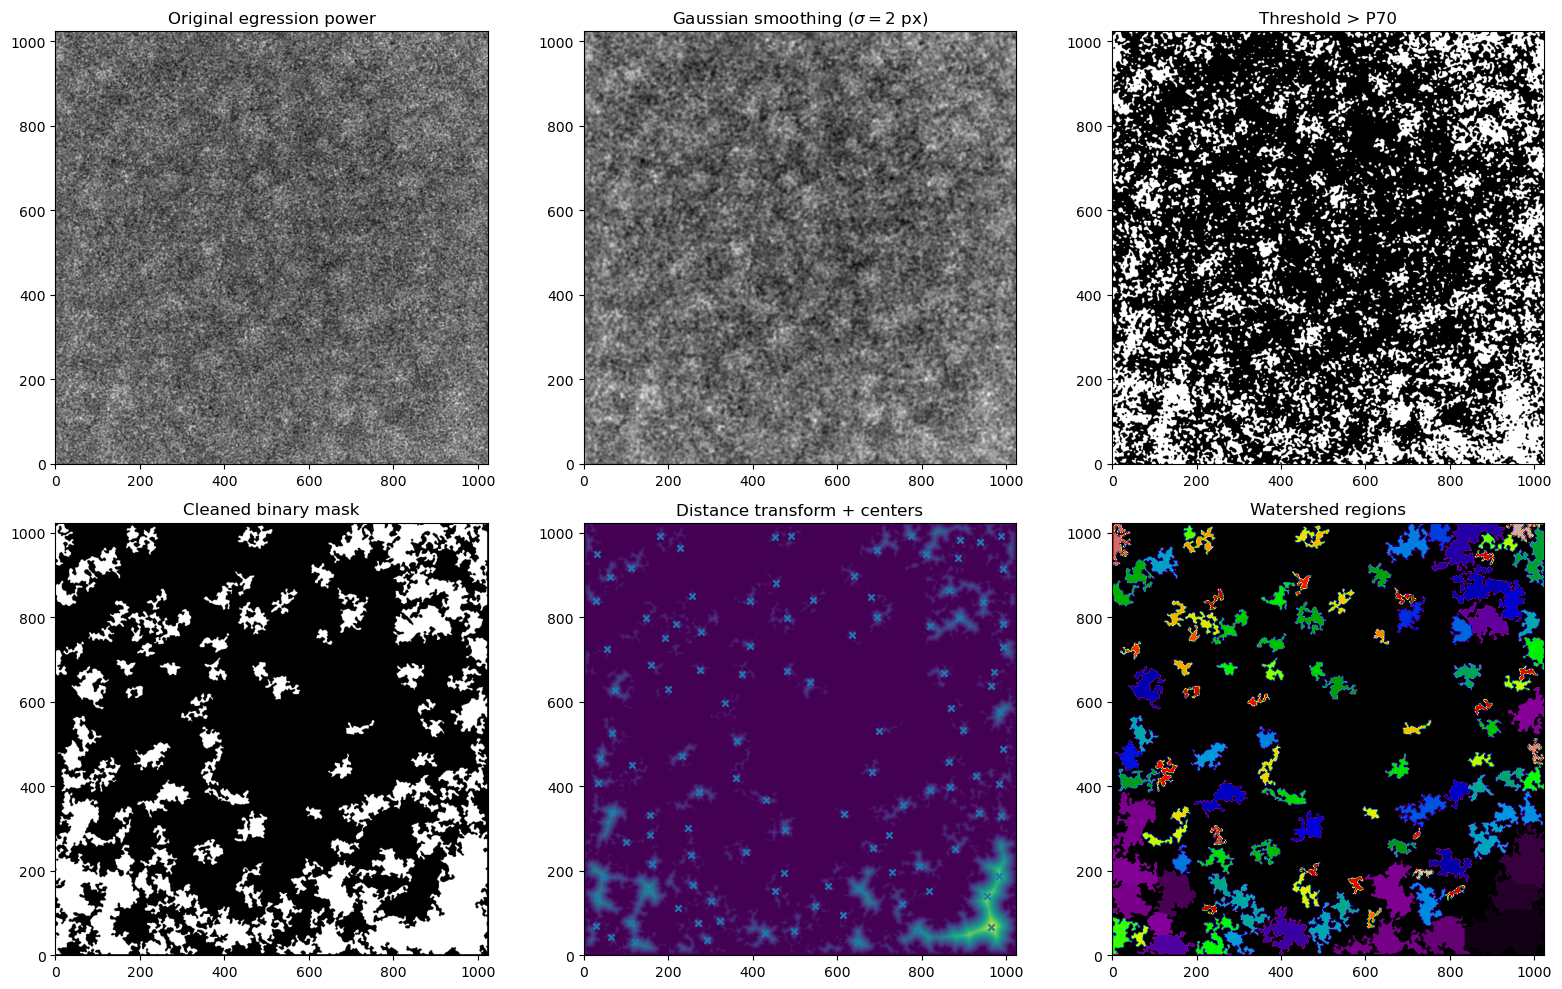

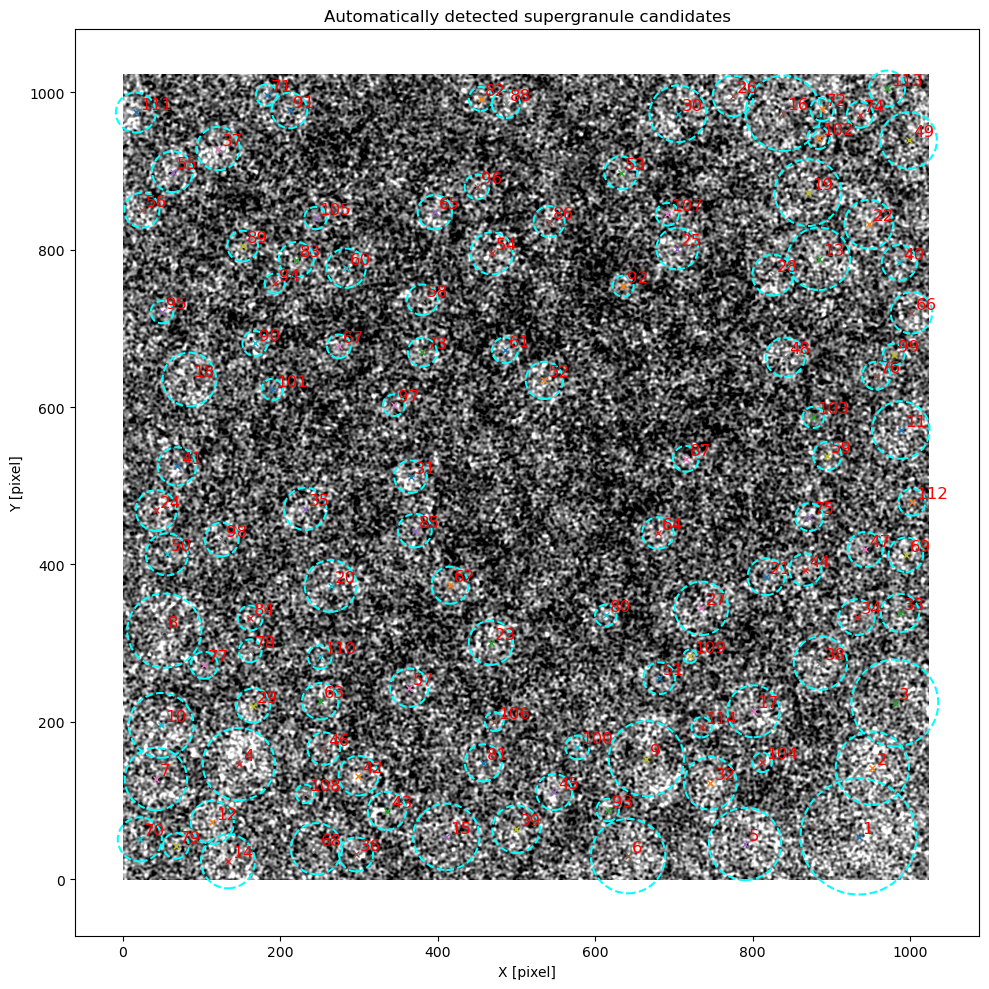

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import (
    gaussian_filter,
    binary_closing,
    binary_fill_holes,
    distance_transform_edt
)

from skimage.morphology import remove_small_objects
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops


# =====================================================
# 1. Original data
# =====================================================

data = egression_pwr_5.astype(float)

# Replace invalid values if present
data[~np.isfinite(data)] = np.nan


# =====================================================
# 2. Smooth the map through a gaussian filter
# =====================================================

sigma = 2

# Fill NaNs temporarily for the Gaussian filter
fill_value = np.nanmedian(data)
data_filled = np.nan_to_num(data, nan=fill_value)

smooth = gaussian_filter(data_filled, sigma=sigma)


# =====================================================
# 3. Threshold bright regions
# =====================================================

percentile_threshold = 70

threshold = np.nanpercentile(smooth, percentile_threshold)

bright_mask = smooth > threshold


# =====================================================
# 4. Morphological cleaning
# =====================================================

# Connect nearby bright patches
clean_mask = binary_closing(
    bright_mask,
    iterations=2
)

# Fill holes inside detected regions
clean_mask = binary_fill_holes(clean_mask)

# Remove very small regions
clean_mask = remove_small_objects(
    clean_mask,
    min_size=500
)


# =====================================================
# 5. Distance transform
# =====================================================

distance = distance_transform_edt(clean_mask)


# =====================================================
# 6. Detect candidate supergranule centers
# =====================================================

coords = peak_local_max(
    distance,
    labels=clean_mask,
    min_distance=30
)

markers = np.zeros_like(distance, dtype=int)

for i, (y, x) in enumerate(coords, start=1):
    markers[y, x] = i


# =====================================================
# 7. Watershed segmentation
# =====================================================

labels = watershed(
    -distance,
    markers,
    mask=clean_mask
)


# =====================================================
# 8. Characterize detected regions
# =====================================================

regions = regionprops(labels)

print(f"Detected regions: {len(regions)}")

supergranules = []

for region in regions:

    cy, cx = region.centroid
    area = region.area

    # Radius of a circle with the same area
    radius = np.sqrt(area / np.pi)

    supergranules.append({
        "x": cx,
        "y": cy,
        "area": area,
        "radius": radius
    })


# =====================================================
# 9. Plot processing steps
# =====================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes = axes.ravel()

# Original
im0 = axes[0].imshow(
    data,
    origin="lower",
    cmap="gray"
)
axes[0].set_title("Original egression power")

# Smoothed
axes[1].imshow(
    smooth,
    origin="lower",
    cmap="gray"
)
axes[1].set_title(f"Gaussian smoothing ($\\sigma={sigma}$ px)")

# Initial threshold
axes[2].imshow(
    bright_mask,
    origin="lower",
    cmap="gray"
)
axes[2].set_title(
    f"Threshold > P{percentile_threshold}"
)

# Cleaned mask
axes[3].imshow(
    clean_mask,
    origin="lower",
    cmap="gray"
)
axes[3].set_title("Cleaned binary mask")

# Distance transform + centers
axes[4].imshow(
    distance,
    origin="lower",
    cmap="viridis"
)

axes[4].scatter(
    coords[:, 1],
    coords[:, 0],
    s=20,
    marker="x"
)

axes[4].set_title("Distance transform + centers")

# Watershed
axes[5].imshow(
    labels,
    origin="lower",
    cmap="nipy_spectral"
)

axes[5].set_title("Watershed regions")

plt.tight_layout()
plt.show()


# =====================================================
# 10. Plot circular supergranule masks
# =====================================================

fig, ax = plt.subplots(figsize=(10, 10))

vmin, vmax = np.nanpercentile(data, [7, 98.5])

ax.imshow(
    data,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

for i, sg in enumerate(supergranules, start=1):

    circle = plt.Circle(
        (sg["x"], sg["y"]),
        sg["radius"],
        fill=False,
        linestyle='--',
        linewidth=1.5,
        color="cyan"
    )

    ax.add_patch(circle)

    ax.plot(
        sg["x"],
        sg["y"],
        marker="x",
        markersize=5
    )

    ax.text(
        sg["x"] + 5,
        sg["y"] + 5,
        str(i),
        fontsize=12,
        color="red"
    )

ax.set_title("Automatically detected supergranule candidates")
ax.set_xlabel("X [pixel]")
ax.set_ylabel("Y [pixel]")

plt.tight_layout()
plt.show()

In [4]:
selected_ids = np.array([55, 37, 18, 29, 31, 42, 65, 52, 23, 64])
selected_ids = np.sort(selected_ids)

selected_supergranules = [
    supergranules[i - 1] for i in selected_ids
]

In [5]:
ny, nx = egression_pwr_5.shape
yy, xx = np.ogrid[:ny, :nx]

individual_masks = {} #dictionary

for sg_id, sg in zip(selected_ids, selected_supergranules):

    mask = (
        (xx - sg["x"])**2 +
        (yy - sg["y"])**2
        <= sg["radius"]**2
    )

    individual_masks[sg_id] = mask

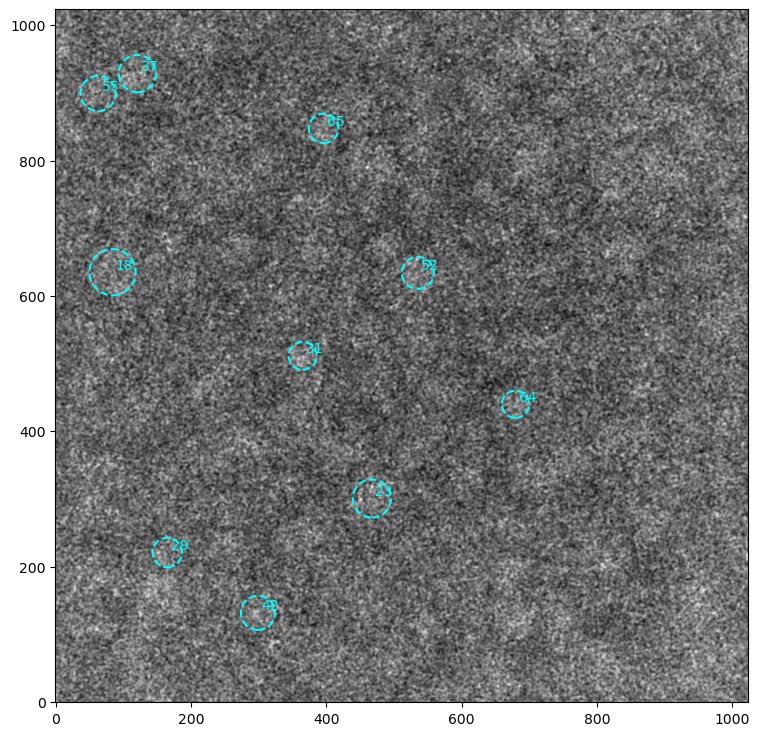

In [6]:
fig, ax = plt.subplots(figsize=(9, 9))

ax.imshow(
    egression_pwr_5,
    origin="lower",
    cmap="gray"
)

for sg_id, sg in zip(
    selected_ids,
    selected_supergranules
):

    circle = plt.Circle(
        (sg["x"], sg["y"]),
        sg["radius"],
        fill=False,
        linewidth=1.5,
        color='cyan',
        linestyle='--'
    )

    ax.add_patch(circle)

    ax.text(
        sg["x"] + 5,
        sg["y"] + 5,
        str(sg_id),
        fontsize=10,
        color='cyan'
    )

plt.show()

In [7]:
# 1. Mean radius of the selected supergranules

radii = np.array([
    sg["radius"] for sg in selected_supergranules
])

mean_radius = np.mean(radii)


# 2. Mean egression power of each individual supergranule

mean_powers = np.array([
    np.nanmean(egression_pwr_5[individual_masks[sg_id]])
    for sg_id in selected_ids
])


# 3. Mean of the individual supergranule means

mean_supergranular_power = np.mean(mean_powers)

pixel_to_arcsec=0.5
arcsec_to_Mm=0.725
# Results
print('The radius of each supergranule in pixels:', np.round(radii, 2))
print('The radius of each supergranule in Mm', np.round(radii*pixel_to_arcsec*arcsec_to_Mm, 2))
print(f"Mean radius: {mean_radius:.2f} pixels or ", "\t", f"{mean_radius*pixel_to_arcsec*arcsec_to_Mm:.2f}Mm")

for sg_id, mean_power in zip(selected_ids, mean_powers):
    print(f"Supergranule {sg_id}: mean power = {mean_power:.4f}")

print(f"\nMean supergranular power: {mean_supergranular_power:.4f}")

The radius of each supergranule in pixels: [34.08 28.11 21.73 20.63 27.47 25.19 23.7  25.89 20.06 21.76]
The radius of each supergranule in Mm [12.35 10.19  7.88  7.48  9.96  9.13  8.59  9.39  7.27  7.89]
Mean radius: 24.86 pixels or  	 9.01Mm
Supergranule 18: mean power = 10212.0811
Supergranule 23: mean power = 10169.5234
Supergranule 29: mean power = 10315.9834
Supergranule 31: mean power = 10455.3701
Supergranule 37: mean power = 10325.2900
Supergranule 42: mean power = 10223.5459
Supergranule 52: mean power = 10246.1172
Supergranule 55: mean power = 10124.7734
Supergranule 64: mean power = 10192.0781
Supergranule 65: mean power = 10171.7051

Mean supergranular power: 10243.6465


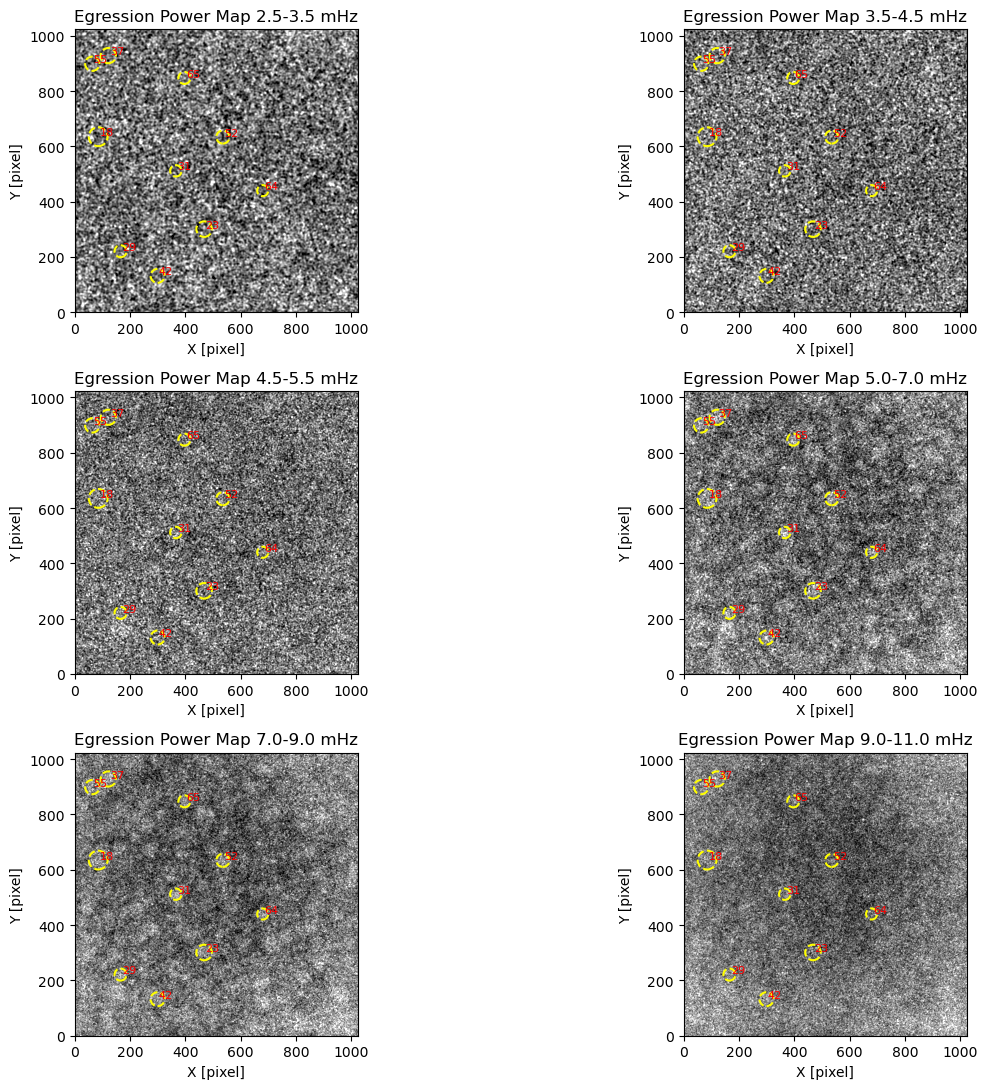

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits


# =====================================================
# Data paths
# =====================================================

base_path = "../data/2018_08_25"

files = {
    "2.5-3.5 mHz": "egress_pwr_02.5-03.5mHz_z0000km.fits",
    "3.5-4.5 mHz": "egress_pwr_03.5-04.5mHz_z0000km.fits",
    "4.5-5.5 mHz": "egress_pwr_04.5-05.5mHz_z0000km.fits",
    "5.0-7.0 mHz": "egress_pwr_05.0-07.0mHz_z0000km.fits",
    "7.0-9.0 mHz": "egress_pwr_07.0-09.0mHz_z0000km.fits",
    "9.0-11.0 mHz": "egress_pwr_09.0-11.0mHz_z0000km.fits",
}

egression_maps = []
# =====================================================
# Plot mosaic
# =====================================================

fig, axes = plt.subplots(
    3, 2,
    figsize=(14, 11)
)

axes = axes.ravel()


for ax, (freq_band, filename) in zip(axes, files.items()):

    path = os.path.join(base_path, filename)

    # Load FITS data
    with fits.open(path) as hdul:
        data = hdul[0].data
    egression_maps.append(data)
    # Contrast using percentiles
    vmin, vmax = np.nanpercentile(data, [1, 99])

    # Plot egression power map
    ax.imshow(
        data,
        origin="lower",
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    # Plot selected supergranules
    for sg_id, sg in zip(
        selected_ids,
        selected_supergranules
    ):

        circle = plt.Circle(
            (sg["x"], sg["y"]),
            sg["radius"],
            fill=False,
            linewidth=1.5,
            linestyle='--',
            color="yellow"
        )

        ax.add_patch(circle)

        ax.text(
            sg["x"] + 5,
            sg["y"] + 5,
            str(sg_id),
            fontsize=8,
            color="red"
        )

    # Title
    ax.set_title(
        f"Egression Power Map {freq_band}"
    )

    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")


plt.tight_layout()
plt.show()

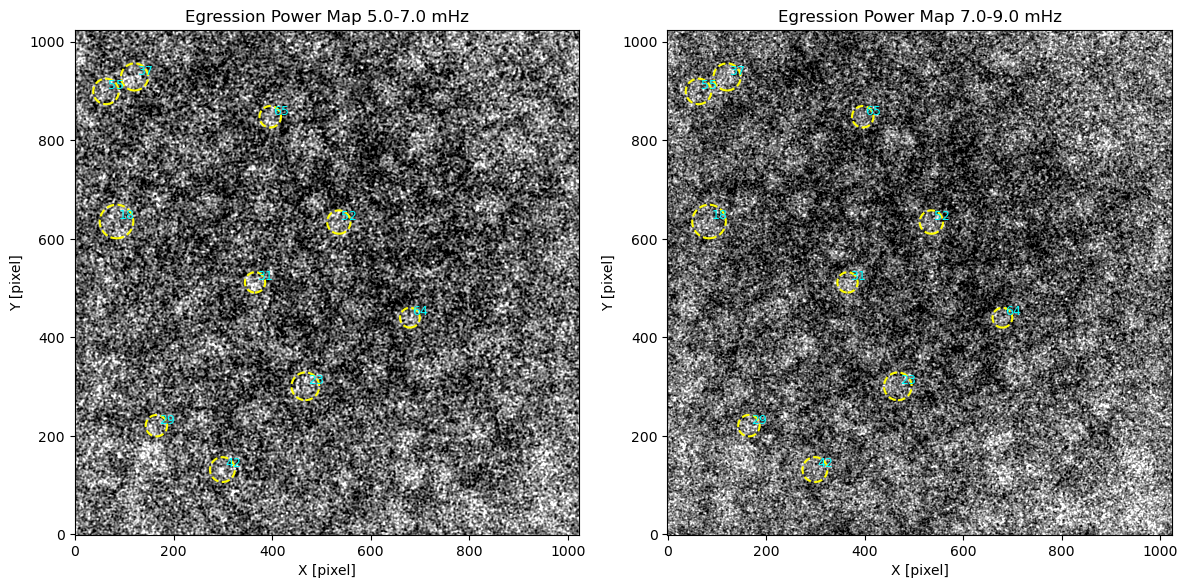

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

indices = [3, 4]
titles = [
    "Egression Power Map 5.0-7.0 mHz",
    "Egression Power Map 7.0-9.0 mHz"
]

for ax, i, title in zip(axes, indices, titles):

    data = egression_maps[i]

    vmin, vmax = np.nanpercentile(data, [7, 98.5])

    ax.imshow(
        data,
        origin="lower",
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    # Plot selected supergranules
    for sg_id, sg in zip(selected_ids, selected_supergranules):

        circle = plt.Circle(
            (sg["x"], sg["y"]),
            sg["radius"],
            fill=False,
            linewidth=1.5,
            linestyle='--',
            color="yellow"
        )

        ax.add_patch(circle)

        ax.text(
            sg["x"] + 5,
            sg["y"] + 5,
            str(sg_id),
            fontsize=9,
            color="cyan"
        )

    ax.set_title(title)
    ax.set_xlabel("X [pixel]")
    ax.set_ylabel("Y [pixel]")

plt.tight_layout()
plt.show()

## Mean value vs Frequency

2.5-3.5 mHz: mean = 265609.4688
3.5-4.5 mHz: mean = 190824.2500
4.5-5.5 mHz: mean = 34519.3594
5.0-7.0 mHz: mean = 9663.4414
7.0-9.0 mHz: mean = 2134.4998
9.0-11.0 mHz: mean = 771.9239


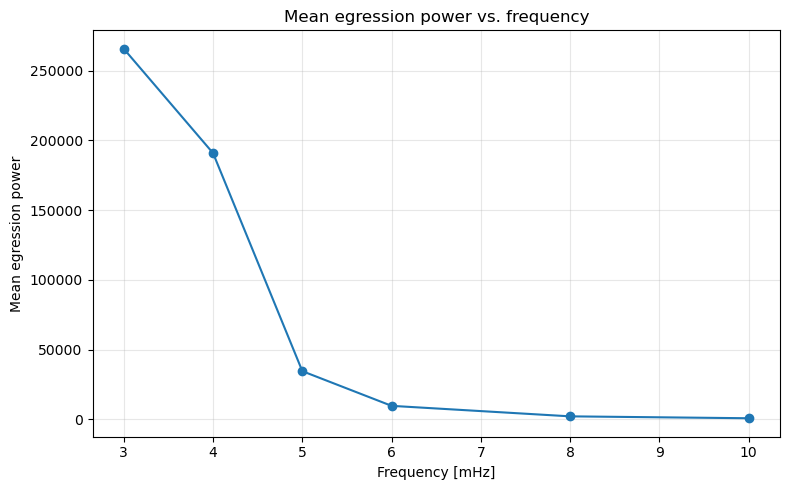

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# =====================================================
# Data paths
# =====================================================

base_path = "../data/2018_08_25"

files = {
    "2.5-3.5 mHz": "egress_pwr_02.5-03.5mHz_z0000km.fits",
    "3.5-4.5 mHz": "egress_pwr_03.5-04.5mHz_z0000km.fits",
    "4.5-5.5 mHz": "egress_pwr_04.5-05.5mHz_z0000km.fits",
    "5.0-7.0 mHz": "egress_pwr_05.0-07.0mHz_z0000km.fits",
    "7.0-9.0 mHz": "egress_pwr_07.0-09.0mHz_z0000km.fits",
    "9.0-11.0 mHz": "egress_pwr_09.0-11.0mHz_z0000km.fits",
}

# Central frequency of each frequency band [mHz]
frequencies = np.array([3, 4, 5, 6, 8, 10])

# =====================================================
# Calculate mean egression power
# =====================================================

mean_power = []

for freq_band, filename in files.items():

    path = os.path.join(base_path, filename)

    with fits.open(path) as hdul:
        data = hdul[0].data

    mean = np.nanmean(data)
    mean_power.append(mean)

    print(
        f"{freq_band}: "
        #f"shape = {data.shape}, "
        f"mean = {mean:.4f}"
    )

# Convert list to NumPy array
mean_power = np.array(mean_power)

# =====================================================
# Plot frequency vs mean egression power
# =====================================================

plt.figure(figsize=(8, 5))

plt.plot(
    frequencies,
    mean_power,
    marker="o"
)

plt.xlabel("Frequency [mHz]")
plt.ylabel("Mean egression power")
plt.title("Mean egression power vs. frequency")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()